<a href="https://colab.research.google.com/github/A-n9ie/proyecto_analisis_datos_IC2026/blob/master/github_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import auth
auth.authenticate_user()
print('Authenticated')

Authenticated


# Función para unir los .CSV de la Biografía de los atletas junto con el de los Resultados de los Juegos Olímpicos

In [7]:
import pandas as pd

def prepare_merged_df(results, bios, start=1896, end=2022):
    df = results.merge(bios[['athlete_id', 'Sex']], on='athlete_id', how='left')

    # Normalizar Sex
    df['Sex'] = df['Sex'].astype(str).str.strip().str.capitalize()
    df.loc[~df['Sex'].isin(['Male', 'Female']), 'Sex'] = pd.NA

    # Limpiar year
    df['year'] = pd.to_numeric(df['year'], errors='coerce')
    df = df[df['year'].between(start, end)]

    # (opcional) quitar filas sin Sex (no se pueden clasificar)
    df = df.dropna(subset=['Sex'])

    return df

In [10]:
bios = pd.read_csv("/content/bios.csv")
results = pd.read_csv("/content/results.csv")
df = prepare_merged_df(results, bios)

# Evolución de porcentaje de participación femenina en los Juegos Olímpicos desde 1896 hasta el 2022

In [ ]:
def female_share_by_year(df):
    grouped = df.groupby(['year', 'Sex']).size().unstack(fill_value=0)

    grouped['total'] = grouped.sum(axis=1)
    grouped['female_share'] = (grouped['Female'] / grouped['total']) * 100

    return grouped.reset_index()

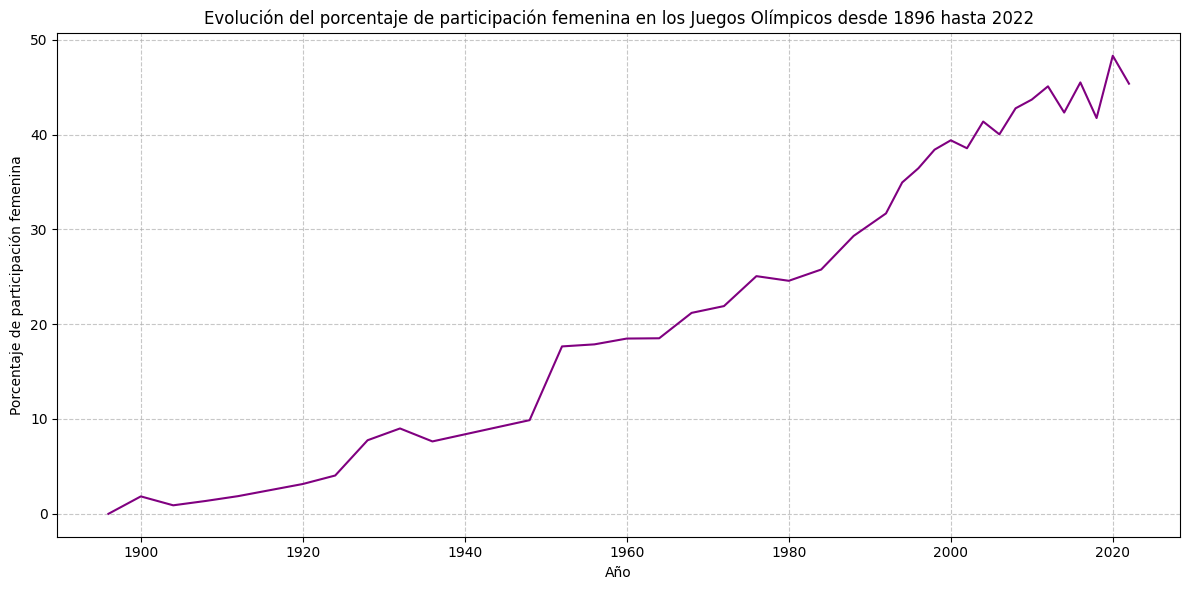

In [ ]:
import matplotlib.pyplot as plt

data = female_share_by_year(df)

plt.figure(figsize=(12, 6)) # Establecer un tamaño de figura para mejor visibilidad
plt.plot(data['year'], data['female_share'], color='purple') # Cambiar el color de la línea
plt.title("Evolución del porcentaje de participación femenina en los Juegos Olímpicos desde 1896 hasta 2022")
plt.xlabel("Año")
plt.ylabel("Porcentaje de participación femenina")
plt.grid(True, linestyle='--', alpha=0.7) # Añadir una cuadrícula para información básica
plt.tight_layout() # Ajustar el diseño para evitar que las etiquetas se corten
plt.show()

# Evoluación del porcentaje de participación femenina desde 1896 hasta 2022 en Summer vs Winter

In [ ]:
import pandas as pd

def female_share_by_year_and_type(df):
    # Conteos por año, tipo (Summer/Winter) y sexo
    grouped = (df.groupby(['year', 'type', 'Sex'])
                 .size()
                 .unstack(fill_value=0)
                 .reset_index())

    # Total por (año,tipo)
    grouped['total'] = grouped.get('Male', 0) + grouped.get('Female', 0)
    grouped['female_share'] = (grouped.get('Female', 0) / grouped['total']) * 100

    return grouped[['year', 'type', 'female_share']]

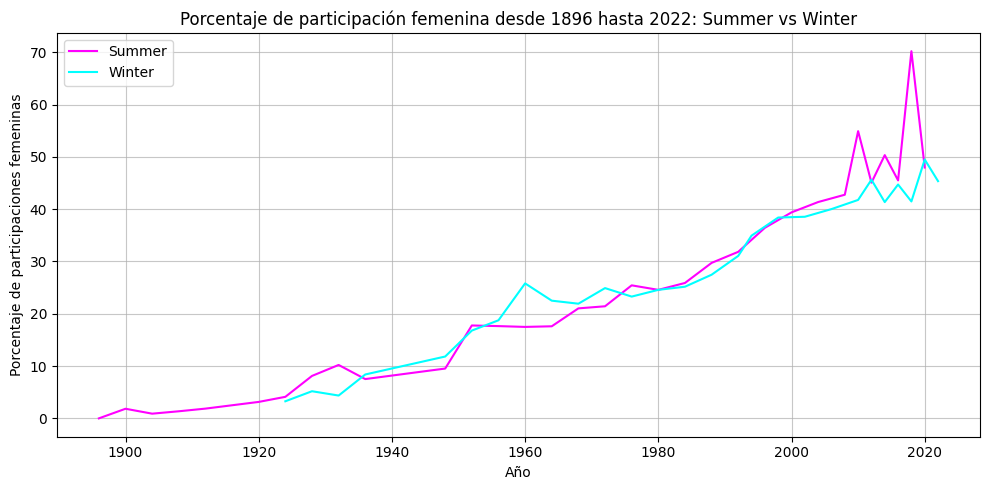

In [ ]:
import matplotlib.pyplot as plt

data_type = female_share_by_year_and_type(df)

plt.figure(figsize=(10,5))

# Definir un diccionario de colores para cada tipo
colors = {'Summer': 'fuchsia', 'Winter': 'aqua'}

for t in sorted(data_type['type'].dropna().unique()):
    sub = data_type[data_type['type'] == t].sort_values('year')
    plt.plot(sub['year'], sub['female_share'], label=t, color=colors.get(t)) # Usar los colores definidos

plt.title("Porcentaje de participación femenina desde 1896 hasta 2022: Summer vs Winter")
plt.xlabel("Año")
plt.ylabel("Porcentaje de participaciones femeninas")
plt.legend()
plt.grid(True, alpha=0.7) # Aumentar la visibilidad de la cuadrícula
plt.tight_layout() # Ajustar el diseño para evitar que las etiquetas se corten
plt.show()

# Top 5 países con más participaciones femeninas

In [ ]:
import pandas as pd

def top_5_nocs_female_entries(df, start=1896, end=2022, games_type=None):
    d = df.copy()
    d['year'] = pd.to_numeric(d['year'], errors='coerce')
    d = d[d['year'].between(start, end)]
    d = d[d['Sex'] == 'Female']

    if games_type is not None:
        d = d[d['type'] == games_type]  # "Summer" o "Winter"

    top = (d.groupby('noc')
            .size()
            .sort_values(ascending=False)
            .head(5)
            .reset_index(name='female_event_entries'))

    return top

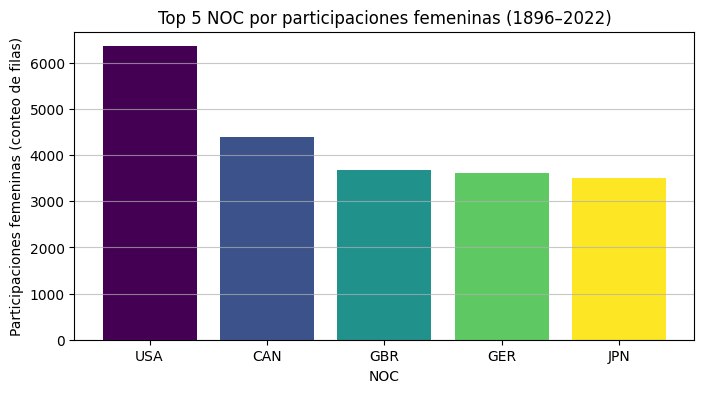

In [ ]:
import matplotlib.pyplot as plt
import numpy as np # Importar numpy para generar un espacio lineal para los colores
top5 = top_5_nocs_female_entries(df)
plt.figure(figsize=(8,4))
# Usar un mapa de colores para las barras, asegurando una distribución más uniforme
colors = plt.cm.viridis(np.linspace(0, 1, len(top5)))
plt.bar(top5['noc'], top5['female_event_entries'], color=colors)
plt.title("Top 5 NOC por participaciones femeninas (1896–2022)")
plt.xlabel("NOC")
plt.ylabel("Participaciones femeninas (conteo de filas)")
plt.grid(axis='y', alpha=0.7) # Aumentar la visibilidad de la cuadrícula
plt.show()

# Top 5 disciplinas con más participación femenina y su evolución

In [ ]:
import pandas as pd

def female_entries_top_disciplines_over_time(df, n=5, start=1896, end=2022, games_type=None):
    d = df.copy()
    d['year'] = pd.to_numeric(d['year'], errors='coerce')
    d = d[d['year'].between(start, end)]
    d = d[d['Sex'] == 'Female']

    if games_type is not None:
        d = d[d['type'] == games_type]

    # Top disciplinas globales
    top_disc = (d.groupby('discipline')
                 .size()
                 .sort_values(ascending=False)
                 .head(n)
                 .index.tolist())

    # Serie temporal solo con esas disciplinas
    series = (d[d['discipline'].isin(top_disc)]
              .groupby(['year', 'discipline'])
              .size()
              .reset_index(name='female_event_entries'))

    return top_disc, series

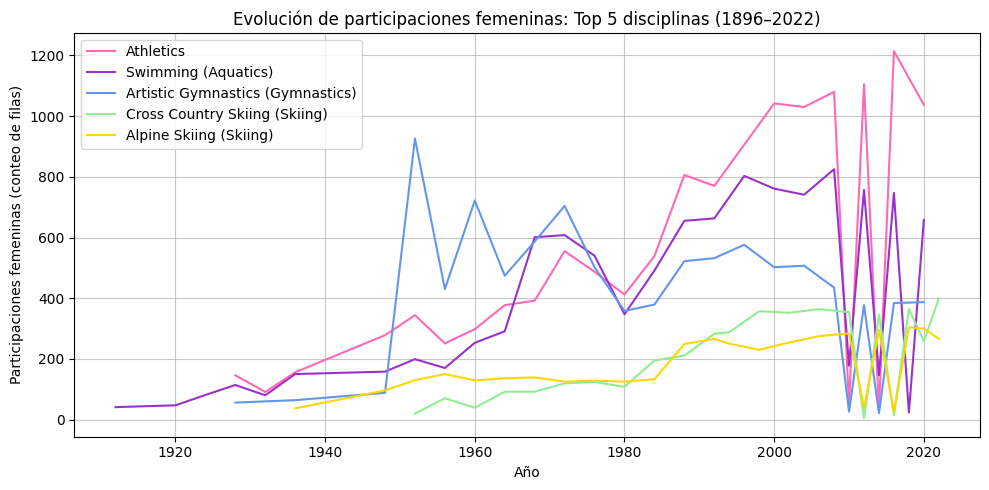

In [ ]:
import matplotlib.pyplot as plt

top_disc, series = female_entries_top_disciplines_over_time(df, n=5)

plt.figure(figsize=(10,5))
# Usar un mapa de colores para las líneas
# Custom "girly" colors: HotPink, DarkOrchid, CornflowerBlue, LightGreen, Gold
custom_line_colors = ['#FF69B4', '#9932CC', '#6495ED', '#90EE90', '#FFD700']

for i, disc in enumerate(top_disc):
    sub = series[series['discipline'] == disc].sort_values('year')
    plt.plot(sub['year'], sub['female_event_entries'], label=disc, color=custom_line_colors[i % len(custom_line_colors)]) # Use custom colors

plt.title("Evolución de participaciones femeninas: Top 5 disciplinas (1896–2022)")
plt.xlabel("Año")
plt.ylabel("Participaciones femeninas (conteo de filas)")
plt.legend()
plt.grid(True, alpha=0.7) # Aumentar la visibilidad de la cuadrícula
plt.tight_layout() # Ajustar el diseño para evitar que las etiquetas se corten
plt.show()

Comparación directa de participaciones masculinas vs femeninas por año en las olimpiadas

In [ ]:
def male_vs_female_entries_by_year(df):
    grouped = df.groupby(['year', 'Sex']).size().unstack(fill_value=0)

    if 'Female' not in grouped.columns:
        grouped['Female'] = 0
    if 'Male' not in grouped.columns:
        grouped['Male'] = 0

    return grouped.reset_index()[['year', 'Female', 'Male']]

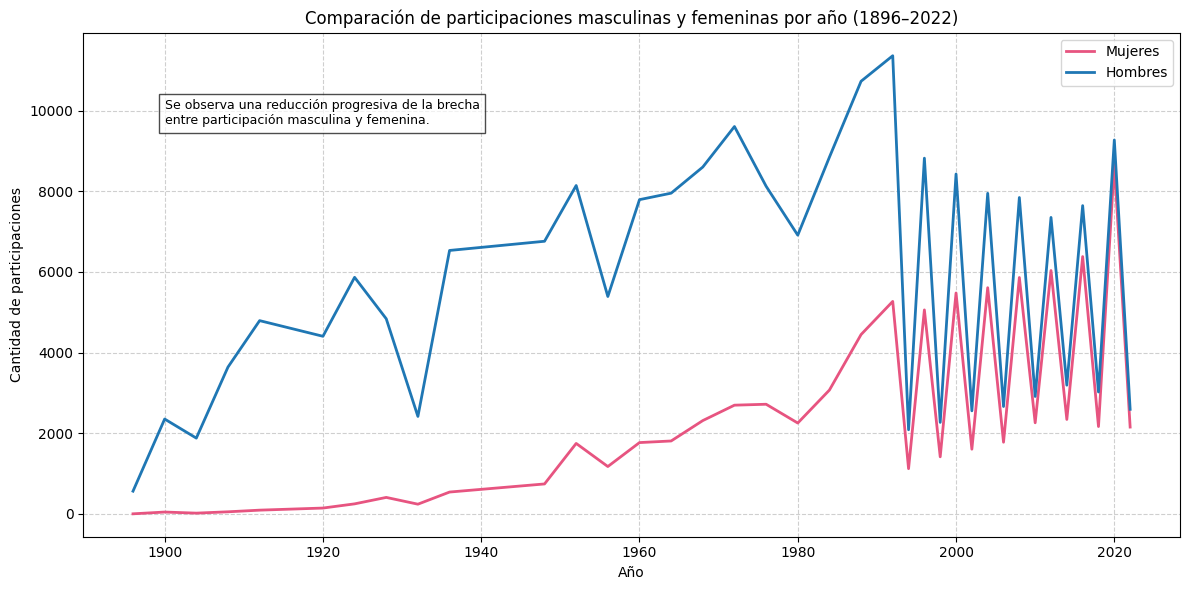

In [ ]:
data_gender = male_vs_female_entries_by_year(df)

plt.figure(figsize=(12,6))
plt.plot(data_gender['year'], data_gender['Female'], label='Mujeres', color='#E75480', linewidth=2)
plt.plot(data_gender['year'], data_gender['Male'], label='Hombres', color='#1F77B4', linewidth=2)

plt.title("Comparación de participaciones masculinas y femeninas por año (1896–2022)")
plt.xlabel("Año")
plt.ylabel("Cantidad de participaciones")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Información básica dentro del gráfico
plt.text(1900, data_gender['Male'].max()*0.85,
         "Se observa una reducción progresiva de la brecha\nentre participación masculina y femenina.",
         fontsize=9,
         bbox=dict(facecolor='white', alpha=0.7))

plt.tight_layout()
plt.show()

Distribución de medallas por sexo

In [ ]:
def medal_counts_by_sex(df):
    d = df.dropna(subset=['medal']).copy()

    grouped = d.groupby(['Sex', 'medal']).size().unstack(fill_value=0)

    for medal in ['Gold', 'Silver', 'Bronze']:
        if medal not in grouped.columns:
            grouped[medal] = 0

    return grouped[['Gold', 'Silver', 'Bronze']].reset_index()

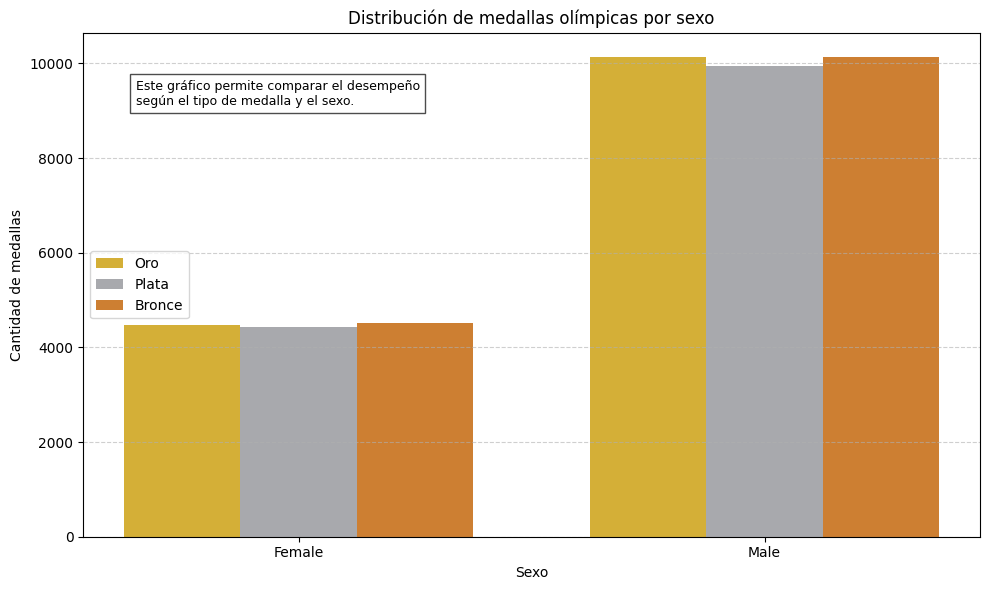

In [ ]:
medals_data = medal_counts_by_sex(df)

x = range(len(medals_data))
width = 0.25

plt.figure(figsize=(10,6))
plt.bar([i - width for i in x], medals_data['Gold'], width=width, label='Oro', color='#D4AF37')
plt.bar(x, medals_data['Silver'], width=width, label='Plata', color='#A8A9AD')
plt.bar([i + width for i in x], medals_data['Bronze'], width=width, label='Bronce', color='#CD7F32')

plt.xticks(x, medals_data['Sex'])
plt.title("Distribución de medallas olímpicas por sexo")
plt.xlabel("Sexo")
plt.ylabel("Cantidad de medallas")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Información básica
plt.text(-0.35, max(medals_data[['Gold','Silver','Bronze']].max())*0.9,
         "Este gráfico permite comparar el desempeño\nsegún el tipo de medalla y el sexo.",
         fontsize=9,
         bbox=dict(facecolor='white', alpha=0.7))

plt.tight_layout()
plt.show()

# PRIMER PARTICIPACIÓN FEMENINA POR DISCIPLINA

In [66]:
def first_female_participation_by_discipline(df):
    # Trabajar sobre una copia para no modificar el original
    d = df.copy()

    # Asegurar que 'year' sea numérico y eliminar filas sin año o disciplina (limpiar)
    d['year'] = pd.to_numeric(d['year'], errors='coerce')
    d = d.dropna(subset=['year', 'discipline'])

    # Filtrar solo registros de mujeres -> participación femenina
    female_df = d[d['Sex'] == 'Female'].copy()

    # Primer año de participación femenina por disciplina
    first_year_by_discipline = female_df.groupby('discipline')['year'].min().reset_index()
    first_year_by_discipline.columns = ['discipline', 'first_female_year']
    first_year_by_discipline['first_female_year'] = first_year_by_discipline['first_female_year'].astype(int)

    # Años transcurridos desde 1896 (inicio de Juegos modernos)
    first_year_by_discipline['years_until_inclusion'] = (
        first_year_by_discipline['first_female_year'] - 1896
    )

    # Total de participaciones femeninas (número de filas) por disciplina
    female_participations = female_df.groupby('discipline').size().reset_index(
        name='total_female_participations'
    )

    # Total de medallas ganadas por mujeres (solo registros con medalla no nula)
    female_medals = female_df.dropna(subset=['medal']).groupby('discipline').size().reset_index(
        name='total_female_medals'
    )

    # Unir todos los DataFrames
    result = first_year_by_discipline.merge(female_participations, on='discipline', how='left')
    result = result.merge(female_medals, on='discipline', how='left')
    result['total_female_medals'] = result['total_female_medals'].fillna(0).astype(int)

    # Tasa de conversión: medallas por cada 100 participaciones
    result['medal_conversion_rate'] = (
        (result['total_female_medals'] / result['total_female_participations']) * 100
    ).round(2)

    # Ordenar por año descendente (las disciplinas más recientes primero)
    result = result.sort_values('first_female_year', ascending=False).reset_index(drop=True)

    # ordenar columnas finales
    columns_order = [
        'discipline',
        'first_female_year',
        'years_until_inclusion',
        'total_female_participations',
        'total_female_medals',
        'medal_conversion_rate'
    ]

    return result[columns_order]

In [68]:
import matplotlib.patheffects as path_effects

def visualize_first_female_participation(df, top_n=15, order='recent'):
    # Cargar los datos de primer año de participación femenina por disciplina
    first_female_data = first_female_participation_by_discipline(df)

    # Obtener los años extremos para la escala de colores
    min_year = first_female_data['first_female_year'].min()
    max_year = first_female_data['first_female_year'].max()

    # Seleccionar según el orden solicitado y definir subtítulo
    if order == 'recent':
        first_female_data = first_female_data.head(top_n)
        subtitle = "Últimas Disciplinas en Incorporar Mujeres"
    else:
        first_female_data = first_female_data.tail(top_n)
        subtitle = "Primeras Disciplinas en Incorporar Mujeres"

    # Ordenar para que el año más antiguo aparezca arriba en el gráfico
    first_female_data = first_female_data.sort_values('first_female_year', ascending=True)

    # Crear la figura y los ejes
    fig, ax = plt.subplots(figsize=(12, 8))

    # Generar colores degradados según el año (más antiguo verde, más reciente rojo)
    colors = plt.cm.RdYlGn_r(
        (first_female_data['first_female_year'] - min_year) /
        (max_year - min_year)
    )

    # Dibujar barras horizontales
    bars = ax.barh(first_female_data['discipline'],
                    first_female_data['first_female_year'],
                    color=colors, alpha=0.85, edgecolor='black', linewidth=1.2)

    # Añadir etiquetas de año y número de participaciones a cada barra
    for bar, year, particip in zip(bars,
                                    first_female_data['first_female_year'],
                                    first_female_data['total_female_participations']):

        # Para años anteriores a 1960, colocar la etiqueta fuera de la barra (a la derecha)
        if year < 1960:
            x_pos = year + 2
            ha = 'left'
        else:
            # Para años más recientes, colocar la etiqueta dentro de la barra (cerca del final)
            x_pos = year - 2
            ha = 'right'

        txt = ax.text(x_pos, bar.get_y() + bar.get_height()/2,
                      f'{int(year)} ({int(particip)} part.)',
                      ha=ha, va='center', fontweight='bold', fontsize=9, color='white')
        # Añadir borde negro al texto para mejorar la legibilidad -> por cambio de color
        txt.set_path_effects([path_effects.withStroke(linewidth=2, foreground='black')])

    # Configurar título, etiquetas de ejes y límites
    ax.set_title(f'Primer Año de Participación Femenina por Disciplina\n{subtitle} (1896-2022)',
                fontsize=13, fontweight='bold', pad=20)
    ax.set_xlabel('Año de Inclusión Femenina', fontsize=11, fontweight='bold')
    ax.set_ylabel('Disciplina Deportiva', fontsize=11, fontweight='bold')
    # limites antes y despues para crear espacio entre borde y barras
    ax.set_xlim(1895, 2025)

    # Activar cuadrícula en el eje X
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)

    # Mostrar el año más antiguo y más reciente fuera del área de las barras
    ax.text(0.5, 1.01,
            f'Año más antiguo: {int(min_year)} | Año más reciente: {int(max_year)}',
            transform=ax.transAxes, ha='center', fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))


    textstr = ('Nota: El color gradual representa la antigüedad de inclusión.\n'
               'Rojo = inclusión más reciente | Verde = inclusión más antigua')
    fig.text(0.5, 0.01, textstr, ha='center', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))


    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.show()

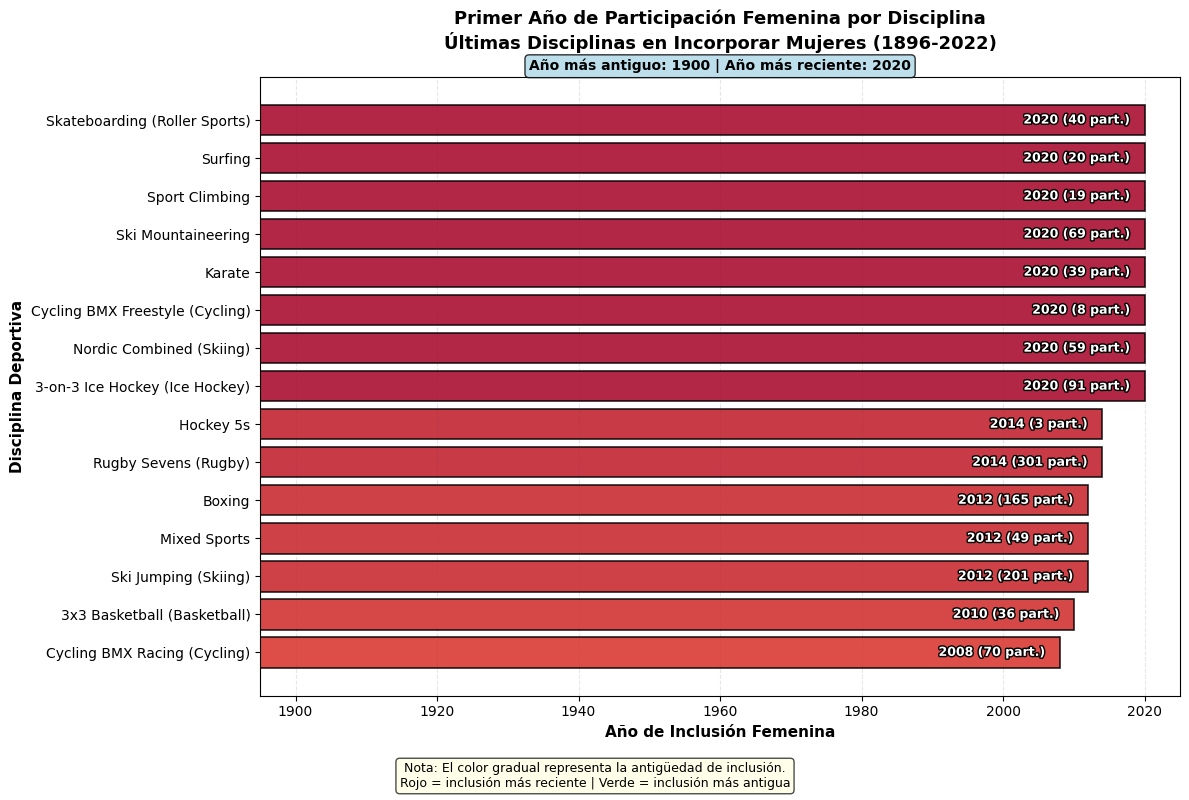

In [69]:
visualize_first_female_participation(df,15)